# Báo cáo phân tích điểm thi THPT

## Hai câu hỏi đáng chú ý từ dữ liệu

Báo cáo đi từ hai câu hỏi rất thực tế khi đọc kết quả thi: khoảng cách giữa các vùng thực sự nằm ở đâu, và liệu kết luận về KHTN–KHXH có thay đổi khi chúng ta dùng một thước đo công bằng hơn hay không?

1. **Khoảng cách điểm giữa Bắc, Trung và Nam bắt nguồn từ môn nào?**
2. **KHTN hay KHXH có lợi thế hơn, hay câu trả lời phụ thuộc vào cách đo?**

### Tóm tắt kết quả

- Khoảng cách giữa các vùng không trải đều trên tất cả các môn. Nếu nhìn vào điểm trung bình, **Ngoại ngữ** có khoảng cách lớn nhất, tiếp theo là **Vật lí**.
- Nếu chuyển sang nhóm đạt từ 8 điểm trở lên, **Ngữ văn** lại là môn có chênh lệch lớn nhất. Nói cách khác, môn tạo ra khác biệt về mặt bằng chung không hoàn toàn trùng với môn tạo ra khác biệt ở nhóm dẫn đầu.
- Theo điểm thô, KHXH cao hơn trong 6/9 tổ hợp vùng–năm. Sau khi chuẩn hóa từng môn theo từng năm, KHTN cao hơn trong cả 9/9 tổ hợp.

Thông điệp chính của báo cáo là: **muốn hiểu đúng khoảng cách kết quả, cần nhìn đồng thời vào môn học, nhóm điểm và cách đo lường.**


## Mục tiêu và phạm vi

### Mục tiêu

Phân tích dữ liệu điểm thi để trả lời hai vấn đề có ý nghĩa cho việc học tập, tư vấn và xây dựng dashboard:

1. Khoảng cách giữa các vùng tập trung ở môn nào?
2. Kết quả KHTN và KHXH có thay đổi như thế nào khi chuyển từ điểm gốc sang điểm tương đối?

Vì vậy, báo cáo không chỉ xếp hạng vùng hoặc ban nào có điểm cao hơn. Trọng tâm là tìm ra **khoảng cách nằm ở đâu, xuất hiện ở nhóm nào và kết luận có phụ thuộc vào cách tính hay không**.

### Phạm vi dữ liệu

| Hạng mục | Phạm vi |
|---|---|
| Chương trình | CT2006 |
| Năm | 2022–2024 |
| Phân tích vùng | Bắc, Trung, Nam; 9 môn thi |
| Phân tích ban | Thí sinh có đủ 5 môn lõi của KHTN hoặc KHXH |
| Đơn vị so sánh | Năm, vùng, môn và ban |
| Dữ liệu thiếu | Giữ nguyên là thiếu, không thay bằng 0 |


In [1]:
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)

candidates = [Path("data/processed/final_data.csv"), Path("../data/processed/final_data.csv")]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/processed/final_data.csv")

SUBJECTS = ["toan", "ngu_van", "ngoai_ngu", "vat_li", "hoa_hoc", "sinh_hoc", "lich_su", "dia_li", "gdcd"]
LABELS = {
    "toan": "Toán",
    "ngu_van": "Ngữ văn",
    "ngoai_ngu": "Ngoại ngữ",
    "vat_li": "Vật lí",
    "hoa_hoc": "Hóa học",
    "sinh_hoc": "Sinh học",
    "lich_su": "Lịch sử",
    "dia_li": "Địa lí",
    "gdcd": "GDCD",
}
SUBJECT_ORDER = SUBJECTS
REGION_ORDER = ["Bắc", "Trung", "Nam"]
USECOLS = ["nam", "chuong_trinh", "ban", "vung_3"] + SUBJECTS

# Thống kê theo năm–vùng–môn:
# số bài hợp lệ, tổng điểm, số điểm từ 8, số điểm dưới 5.
regional_stats = defaultdict(lambda: [0, 0.0, 0, 0])

# Histogram theo từng 0,01 điểm để tính trung vị mà không phải giữ toàn bộ dữ liệu trong bộ nhớ.
regional_hist = defaultdict(lambda: np.zeros(1001, dtype=np.int64))

# Tham số phân phối cấp quốc gia theo năm–môn: n, tổng điểm, tổng bình phương.
national = defaultdict(lambda: [0, 0.0, 0.0])

# Thống kê ban: số dòng, số dòng đủ 5 môn lõi, tổng điểm trung bình lõi,
# số dòng có điểm lõi TB từ 7 và từ 8.
ban_stats = defaultdict(lambda: [0, 0, 0.0, 0, 0])
ban_subject_sums = defaultdict(lambda: [0, 0.0])

for chunk in pd.read_csv(
    DATA_PATH,
    usecols=USECOLS,
    chunksize=500_000,
    low_memory=False,
    dtype={"chuong_trinh": "string", "ban": "string"},
):
    d = chunk[
        (chunk["nam"].between(2022, 2024))
        & (chunk["chuong_trinh"] == "2006")
    ].copy()

    if d.empty:
        continue

    for col in SUBJECTS:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    # Phân tích khoảng cách vùng: mỗi môn dùng toàn bộ thí sinh có điểm hợp lệ ở môn đó.
    for (year, region), group in d.groupby(["nam", "vung_3"], sort=False):
        year, region = int(year), str(region)
        for col in SUBJECTS:
            values = group[col].dropna().to_numpy(dtype=float)
            if len(values) == 0:
                continue

            key = (year, region, col)
            item = regional_stats[key]
            item[0] += len(values)
            item[1] += float(values.sum())
            item[2] += int((values >= 8).sum())
            item[3] += int((values < 5).sum())

            rounded = np.clip(np.rint(values * 100).astype(int), 0, 1000)
            regional_hist[key] += np.bincount(rounded, minlength=1001)

    # Phân phối quốc gia dùng để chuẩn hóa điểm trong câu hỏi 2.
    for year, group in d.groupby("nam", sort=False):
        year = int(year)
        for col in SUBJECTS:
            values = group[col].dropna().to_numpy(dtype=float)
            item = national[(year, col)]
            item[0] += len(values)
            item[1] += float(values.sum())
            item[2] += float((values * values).sum())

    # Phân tích KHTN–KHXH.
    for (year, region, ban), group in d[
        d["ban"].isin(["KHTN", "KHXH"])
    ].groupby(["nam", "vung_3", "ban"], sort=False):
        year, region, ban = int(year), str(region), str(ban)
        core_cols = (
            ["toan", "ngu_van", "vat_li", "hoa_hoc", "sinh_hoc"]
            if ban == "KHTN"
            else ["toan", "ngu_van", "lich_su", "dia_li", "gdcd"]
        )
        core = group[core_cols].dropna()
        core_mean = core.mean(axis=1)
        key = (year, region, ban)
        item = ban_stats[key]
        item[0] += len(group)
        item[1] += len(core_mean)
        item[2] += float(core_mean.sum())
        item[3] += int((core_mean >= 7).sum())
        item[4] += int((core_mean >= 8).sum())

        for col in core_cols:
            item2 = ban_subject_sums[(key, col)]
            item2[0] += len(core)
            item2[1] += float(core[col].sum())

print(f"Đã đọc dữ liệu CT2006 2022–2024 từ: {DATA_PATH}")
print(f"Số nhóm năm–vùng–môn: {len(regional_stats)}")


Đã đọc dữ liệu CT2006 2022–2024; số nhóm năm–vùng–môn: 81


## 1. Khoảng cách điểm giữa Bắc, Trung và Nam bắt nguồn từ môn nào?

### Câu hỏi

Nếu nói một vùng có kết quả thi cao hơn vùng khác, chúng ta đang nói đến toàn bộ các môn hay chỉ một vài môn cụ thể? Môn nào tạo ra khoảng cách lớn nhất giữa Bắc, Trung và Nam? Khoảng cách đó có giống nhau khi nhìn vào mặt bằng chung và nhóm đạt điểm cao hay không?

### Vì sao cần phân tích?

Một nhận xét như “vùng này học tốt hơn vùng kia” thường gộp nhiều môn thành một con số. Cách nhìn đó có thể bỏ qua thực tế rằng mỗi vùng có thể mạnh ở một số môn nhưng không vượt trội ở những môn khác.

Việc tách khoảng cách theo môn giúp câu trả lời cụ thể hơn: nếu muốn thu hẹp chênh lệch, cần biết chênh lệch đang nằm ở đâu; nếu muốn đánh giá nhóm học sinh xuất sắc, cần biết vùng nào có nhiều thí sinh đạt điểm cao hơn chứ không chỉ có điểm trung bình cao hơn.

### Phương pháp

- Phân tích 9 môn thi của CT2006 trong giai đoạn 2022–2024.
- Với mỗi năm, vùng và môn, tính điểm trung bình, trung vị và tỷ lệ đạt từ 8 điểm trở lên.
- Với từng môn, xác định khoảng cách giữa vùng cao nhất và vùng thấp nhất.
- Đối chiếu hai góc nhìn:
  - **Mặt bằng chung:** khoảng cách về điểm trung bình và trung vị.
  - **Nhóm dẫn đầu:** khoảng cách về tỷ lệ đạt từ 8 điểm.
- Chỉ sử dụng những bài thi có điểm hợp lệ ở môn đang phân tích; điểm thiếu không được quy đổi thành 0.


In [2]:
regional_rows = []
for (year, region, col), item in sorted(regional_stats.items()):
    n, total, ge8, lt5 = item
    cumulative = np.cumsum(regional_hist[(year, region, col)])
    middle_positions = [(n - 1) // 2, n // 2]
    middle_values = [
        np.searchsorted(cumulative, position + 1, side="left")
        for position in middle_positions
    ]
    median = float(np.mean(middle_values)) / 100

    regional_rows.append(
        {
            "Năm": year,
            "Vùng": region,
            "Môn": LABELS[col],
            "Môn_code": col,
            "Số bài hợp lệ": n,
            "Điểm trung bình": total / n,
            "Trung vị": median,
            "Từ 8 điểm (%)": 100 * ge8 / n,
            "Dưới 5 điểm (%)": 100 * lt5 / n,
        }
    )

regional_df = pd.DataFrame(regional_rows)
regional_df["Môn"] = pd.Categorical(
    regional_df["Môn"],
    categories=[LABELS[col] for col in SUBJECT_ORDER],
    ordered=True,
)
regional_df["Vùng"] = pd.Categorical(
    regional_df["Vùng"],
    categories=REGION_ORDER,
    ordered=True,
)

gap_rows = []
for (year, subject), group in regional_df.groupby(["Năm", "Môn"], observed=True):
    mean_high = group.loc[group["Điểm trung bình"].idxmax()]
    mean_low = group.loc[group["Điểm trung bình"].idxmin()]
    gap_rows.append(
        {
            "Năm": year,
            "Môn": subject,
            "Vùng cao nhất (TB)": mean_high["Vùng"],
            "Vùng thấp nhất (TB)": mean_low["Vùng"],
            "Khoảng cách TB (điểm)": mean_high["Điểm trung bình"] - mean_low["Điểm trung bình"],
            "Khoảng cách trung vị (điểm)": group["Trung vị"].max() - group["Trung vị"].min(),
            "Chênh lệch từ 8 (điểm %)": group["Từ 8 điểm (%)"].max() - group["Từ 8 điểm (%)"].min(),
        }
    )

gap_df = pd.DataFrame(gap_rows)
subject_summary = (
    gap_df.groupby("Môn", observed=True)
    .agg(
        {
            "Khoảng cách TB (điểm)": "mean",
            "Khoảng cách trung vị (điểm)": "mean",
            "Chênh lệch từ 8 (điểm %)": "mean",
        }
    )
    .reset_index()
    .sort_values("Khoảng cách TB (điểm)", ascending=False)
)

display(Markdown("### Bảng 1 — Khoảng cách giữa vùng cao nhất và thấp nhất theo từng môn"))
display(
    gap_df[
        [
            "Năm",
            "Môn",
            "Vùng cao nhất (TB)",
            "Vùng thấp nhất (TB)",
            "Khoảng cách TB (điểm)",
            "Khoảng cách trung vị (điểm)",
            "Chênh lệch từ 8 (điểm %)",
        ]
    ].round(2)
)

display(Markdown("### Bảng 2 — Mức chênh lệch trung bình trong giai đoạn 2022–2024"))
display(subject_summary.round(2))

display(Markdown(
    "Mỗi dòng cho biết khoảng cách giữa vùng có kết quả cao nhất và vùng có kết quả thấp nhất. "
    "Ví dụ, nếu **Chênh lệch từ 8 = 15 điểm %**, nghĩa là tỷ lệ thí sinh đạt từ 8 điểm "
    "ở hai vùng chênh nhau khoảng 15 điểm phần trăm."
))


### Bảng 1 — Khoảng cách giữa vùng cao nhất và thấp nhất theo từng môn

 Năm       Môn Vùng cao nhất (TB) Vùng thấp nhất (TB)  Khoảng cách TB (điểm)  Khoảng cách trung vị (điểm)  Chênh lệch từ 8 (điểm %)
2022      Toán                Nam               Trung                   0.30                         0.20                      4.98
2022   Ngữ văn                Bắc                 Nam                   0.32                         0.25                     13.10
2022 Ngoại ngữ                Nam               Trung                   0.61                         0.80                      5.31
2022    Vật lí                Bắc                 Nam                   0.55                         0.75                     17.01
2022   Hóa học                Bắc                 Nam                   0.29                         0.50                     12.31
2022  Sinh học                Nam               Trung                   0.21                         0.25                      0.47
2022   Lịch sử                Bắc               Trung                   0.36

### Bảng 2 — Mức chênh lệch trung bình trong giai đoạn 2022–2024

      Môn  Khoảng cách TB (điểm)  Khoảng cách trung vị (điểm)  Chênh lệch từ 8 (điểm %)
Ngoại ngữ                   0.56                         0.73                      5.66
   Vật lí                   0.53                         0.67                     15.69
  Ngữ văn                   0.37                         0.50                     16.00
     GDCD                   0.33                         0.33                     11.70
     Toán                   0.33                         0.20                      4.94
  Lịch sử                   0.28                         0.33                      5.40
 Sinh học                   0.22                         0.25                      1.37
   Địa lí                   0.22                         0.25                      4.66
  Hóa học                   0.19                         0.25                     10.00

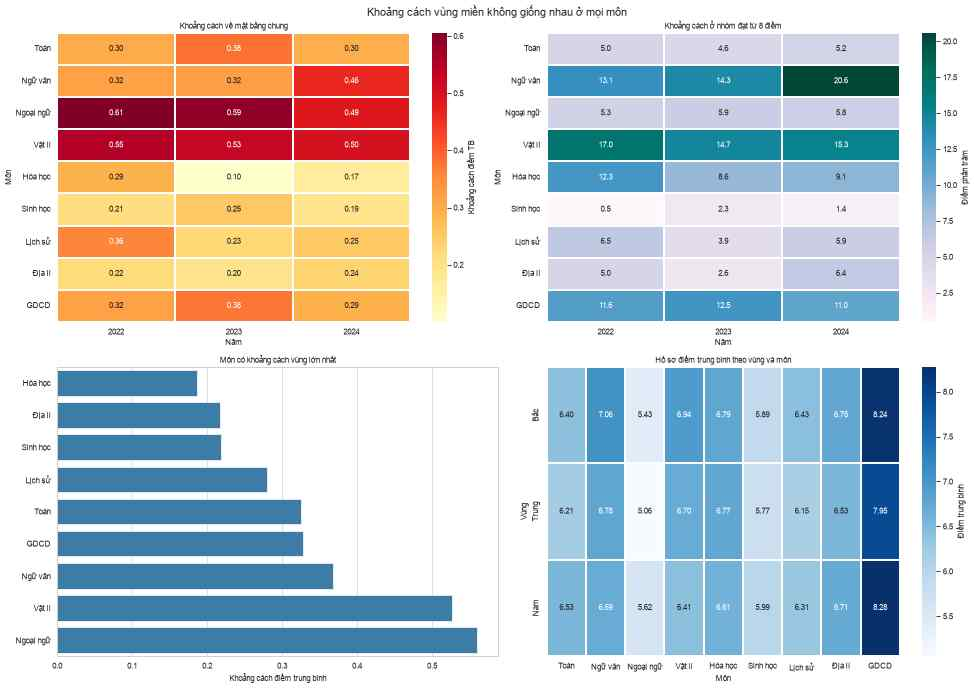

In [3]:
mean_gap_matrix = gap_df.pivot(index="Môn", columns="Năm", values="Khoảng cách TB (điểm)")
high_gap_matrix = gap_df.pivot(index="Môn", columns="Năm", values="Chênh lệch từ 8 (điểm %)")

regional_profile = (
    regional_df.groupby(["Vùng", "Môn"], observed=True)["Điểm trung bình"]
    .mean()
    .unstack()
    .reindex(REGION_ORDER)
    .reindex(columns=[LABELS[col] for col in SUBJECT_ORDER])
)

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.ravel()

sns.heatmap(
    mean_gap_matrix.reindex([LABELS[col] for col in SUBJECT_ORDER]),
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=.5,
    ax=axes[0],
    cbar_kws={"label": "Khoảng cách điểm TB"},
)
axes[0].set_title("Khoảng cách về mặt bằng chung")
axes[0].set_xlabel("Năm")
axes[0].set_ylabel("Môn")

sns.heatmap(
    high_gap_matrix.reindex([LABELS[col] for col in SUBJECT_ORDER]),
    annot=True,
    fmt=".1f",
    cmap="PuBuGn",
    linewidths=.5,
    ax=axes[1],
    cbar_kws={"label": "Điểm phần trăm"},
)
axes[1].set_title("Khoảng cách ở nhóm đạt từ 8 điểm")
axes[1].set_xlabel("Năm")
axes[1].set_ylabel("Môn")

plot_summary = subject_summary.sort_values("Khoảng cách TB (điểm)", ascending=True)
sns.barplot(
    data=plot_summary,
    x="Khoảng cách TB (điểm)",
    y="Môn",
    color="#2c7fb8",
    ax=axes[2],
)
axes[2].set_title("Môn có khoảng cách vùng lớn nhất")
axes[2].set_xlabel("Khoảng cách điểm trung bình")
axes[2].set_ylabel("")

sns.heatmap(
    regional_profile,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=.5,
    ax=axes[3],
    cbar_kws={"label": "Điểm trung bình"},
)
axes[3].set_title("Hồ sơ điểm trung bình theo vùng và môn")
axes[3].set_xlabel("Môn")
axes[3].set_ylabel("Vùng")

fig.suptitle(
    "Khoảng cách vùng miền không giống nhau ở mọi môn",
    fontsize=16,
)
fig.tight_layout()
plt.show()


## 1. Kết quả và diễn giải

### Kết quả chính

- Xét điểm trung bình trong cả ba năm, **Ngoại ngữ có khoảng cách vùng lớn nhất**, trung bình khoảng **0,56 điểm** giữa vùng cao nhất và thấp nhất. **Vật lí** đứng ngay sau với khoảng **0,53 điểm**.
- Xét tỷ lệ đạt từ 8 điểm, thứ hạng thay đổi: **Ngữ văn có chênh lệch lớn nhất**, khoảng **16 điểm phần trăm** giữa các vùng; Vật lí đứng thứ hai với khoảng **15,7 điểm phần trăm**.
- Vùng Trung có điểm trung bình thấp nhất ở **18/27 tổ hợp môn–năm**. Tuy nhiên, không có vùng nào luôn đứng đầu ở tất cả các môn.
- Trong trung bình giai đoạn 2022–2024, Bắc nổi bật hơn ở Ngữ văn và Vật lí; Nam nổi bật hơn ở Toán, Ngoại ngữ, Sinh học và GDCD. Lợi thế vùng vì thế mang tính **theo môn**, không phải một thứ hạng cố định cho mọi môn.

### Trả lời

**Khoảng cách vùng miền không nằm ở một môn duy nhất. Ngoại ngữ là môn tạo ra khoảng cách lớn nhất về điểm trung bình, còn Ngữ văn tạo ra khoảng cách lớn nhất trong nhóm đạt điểm cao.**

Đây là kết quả đáng chú ý vì hai cách đo đưa đến hai câu chuyện khác nhau. Ngoại ngữ phản ánh sự khác biệt rõ hơn ở mặt bằng chung, trong khi Ngữ văn phân hóa mạnh hơn ở nhóm thí sinh đạt từ 8 điểm. Do đó, câu hỏi “vùng nào học tốt hơn?” chưa đủ cụ thể nếu chưa nói rõ đang xét mặt bằng chung hay nhóm dẫn đầu.

### Hàm ý

- Nếu mục tiêu là cải thiện mặt bằng chung, Ngoại ngữ và Vật lí là hai môn nên được ưu tiên phân tích sâu hơn.
- Nếu mục tiêu là mở rộng nhóm học sinh đạt thành tích cao, Ngữ văn và Vật lí cho thấy khoảng cách đáng chú ý hơn.
- Dashboard nên cho phép chuyển đổi giữa điểm trung bình, trung vị và tỷ lệ đạt ngưỡng thay vì chỉ hiển thị một bảng xếp hạng vùng tổng hợp.
- Khi đưa ra khuyến nghị cho từng vùng, nên dựa trên môn cụ thể thay vì gán một nhận xét chung cho toàn vùng.

### Giới hạn

Phân tích cho thấy sự khác biệt quan sát được giữa các vùng nhưng không xác định nguyên nhân của khác biệt đó. Kết quả có thể đồng thời chịu ảnh hưởng của độ khó đề, lựa chọn môn thi, điều kiện học tập và thành phần thí sinh. Ngoài ra, mỗi môn có số lượng bài hợp lệ khác nhau; tỷ lệ và điểm trung bình của từng môn được tính trên chính số bài hợp lệ của môn đó.


## 2. KHTN hay KHXH: lợi thế nằm ở học lực hay ở thước đo?

### Câu hỏi

Khi so sánh KHTN và KHXH, ban nào thực sự có kết quả tốt hơn? Câu trả lời có còn giống nhau nếu chúng ta chuyển từ điểm gốc sang vị trí tương đối so với những thí sinh thi cùng môn trong cùng năm?

### Vì sao cần phân tích?

Điểm của các môn thi không nằm trên cùng một mặt bằng. Có môn thường có điểm trung bình cao, trong khi có môn có mặt bằng thấp hơn. Vì vậy, điểm trung bình của một ban có thể chịu ảnh hưởng bởi việc ban đó gồm những môn nào, chứ chưa phản ánh đầy đủ vị trí của thí sinh so với những người thi cùng môn.

Đây là điểm quan trọng khi xây dựng bảng xếp hạng. Một phép tính có thể hoàn toàn đúng về mặt số học nhưng vẫn chưa trả lời đúng câu hỏi về năng lực tương đối.

### Phương pháp

- KHTN gồm Toán, Ngữ văn, Vật lí, Hóa học và Sinh học.
- KHXH gồm Toán, Ngữ văn, Lịch sử, Địa lí và GDCD.
- Chỉ giữ những thí sinh có đủ 5 môn lõi của ban tương ứng.
- Tính hai chỉ số:
  - **Điểm thô:** trung bình của 5 điểm gốc.
  - **Điểm tương đối:** chuẩn hóa từng môn theo mặt bằng điểm của chính môn đó trong cùng năm, rồi lấy trung bình.
- So sánh KHTN và KHXH trên 3 vùng trong 3 năm.


In [4]:
national_params = {}
for (year_col, item) in national.items():
    year, col = year_col
    n, total, sum_sq = item
    mean = total / n
    sd = np.sqrt(max(sum_sq / n - mean ** 2, 0))
    national_params[(year, col)] = (mean, sd)

ban_rows = []
for (year, region, ban), item in sorted(ban_stats.items()):
    total_ban, n_complete, raw_sum, ge7, ge8 = item
    if n_complete == 0:
        continue
    same_region = sum(ban_stats[(year, region, b)][0] for b in ["KHTN", "KHXH"])
    core_cols = (
        ["toan", "ngu_van", "vat_li", "hoa_hoc", "sinh_hoc"]
        if ban == "KHTN"
        else ["toan", "ngu_van", "lich_su", "dia_li", "gdcd"]
    )
    z_means = []
    for col in core_cols:
        n_col, sum_col = ban_subject_sums[((year, region, ban), col)]
        mean, sd = national_params[(year, col)]
        z_means.append(((sum_col / n_col) - mean) / sd)
    ban_rows.append({
        "Năm": year,
        "Vùng": region,
        "Ban": ban,
        "Tỷ trọng trong vùng (%)": 100 * total_ban / same_region,
        "Đủ 5 môn lõi": n_complete,
        "Điểm thô TB": raw_sum / n_complete,
        "Điểm tương đối TB": float(np.mean(z_means)),
        "Lõi từ 7 (%)": 100 * ge7 / n_complete,
        "Lõi từ 8 (%)": 100 * ge8 / n_complete,
    })

ban_df = pd.DataFrame(ban_rows)
example = ban_df[(ban_df["Năm"] == 2022) & (ban_df["Vùng"] == "Bắc")][[
    "Ban", "Tỷ trọng trong vùng (%)", "Điểm thô TB", "Điểm tương đối TB", "Lõi từ 7 (%)"
]]
display(Markdown("### Ví dụ: Bắc năm 2022"))
display(example.round(2))

raw_pivot = ban_df.pivot_table(index=["Năm", "Vùng"], columns="Ban", values="Điểm thô TB")
relative_pivot = ban_df.pivot_table(index=["Năm", "Vùng"], columns="Ban", values="Điểm tương đối TB")
diff_df = pd.DataFrame({
    "Điểm thô: KHTN−KHXH": raw_pivot["KHTN"] - raw_pivot["KHXH"],
    "Điểm tương đối: KHTN−KHXH": relative_pivot["KHTN"] - relative_pivot["KHXH"],
}).reset_index()

display(Markdown("### Toàn bộ 9 tổ hợp vùng–năm"))
display(diff_df.round(3))
raw_wins = int((diff_df["Điểm thô: KHTN−KHXH"] > 0).sum())
relative_wins = int((diff_df["Điểm tương đối: KHTN−KHXH"] > 0).sum())
display(Markdown(
    f"**KHTN cao hơn theo điểm thô:** {raw_wins}/9 tổ hợp.  "
    f"**KHTN cao hơn sau chuẩn hóa:** {relative_wins}/9 tổ hợp."
))

### Ví dụ: Bắc năm 2022

 Ban  Tỷ trọng trong vùng (%)  Điểm thô TB  Điểm tương đối TB  Lõi từ 7 (%)
KHTN                    26.44         6.74               0.29         41.54
KHXH                    73.56         6.96               0.12         52.97

### Toàn bộ 9 tổ hợp vùng–năm

 Năm  Vùng  Điểm thô: KHTN−KHXH  Điểm tương đối: KHTN−KHXH
2022   Bắc               -0.218                      0.170
2022   Nam               -0.341                      0.095
2022 Trung               -0.061                      0.292
2023   Bắc                0.157                      0.176
2023   Nam                0.013                      0.087
2023 Trung                0.267                      0.264
2024   Bắc               -0.194                      0.153
2024   Nam               -0.326                      0.078
2024 Trung               -0.063                      0.264

**KHTN cao hơn theo điểm thô:** 3/9 tổ hợp.  **KHTN cao hơn sau chuẩn hóa:** 9/9 tổ hợp.

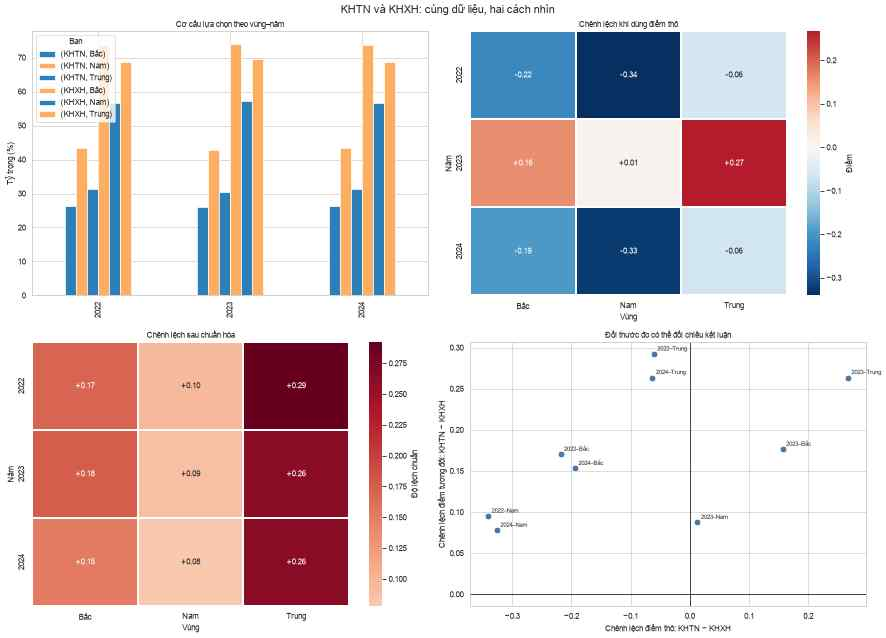

In [5]:
share = ban_df.pivot_table(
    index=["Năm", "Vùng"], columns="Ban", values="Tỷ trọng trong vùng (%)"
).unstack("Vùng")

raw_diff = diff_df.pivot(index="Năm", columns="Vùng", values="Điểm thô: KHTN−KHXH")
relative_diff = diff_df.pivot(index="Năm", columns="Vùng", values="Điểm tương đối: KHTN−KHXH")

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
axes = axes.ravel()

share.plot(kind="bar", ax=axes[0], color=["#2c7fb8", "#fdae61"])
axes[0].set_title("Cơ cấu lựa chọn theo vùng–năm")
axes[0].set_ylabel("Tỷ trọng (%)")
axes[0].set_xlabel("")
axes[0].legend(title="Ban")

sns.heatmap(
    raw_diff,
    annot=True,
    fmt="+.2f",
    center=0,
    cmap="RdBu_r",
    linewidths=.5,
    ax=axes[1],
    cbar_kws={"label": "Điểm"},
)
axes[1].set_title("Chênh lệch khi dùng điểm thô")
axes[1].set_xlabel("Vùng")
axes[1].set_ylabel("Năm")

sns.heatmap(
    relative_diff,
    annot=True,
    fmt="+.2f",
    center=0,
    cmap="RdBu_r",
    linewidths=.5,
    ax=axes[2],
    cbar_kws={"label": "Độ lệch chuẩn"},
)
axes[2].set_title("Chênh lệch sau chuẩn hóa")
axes[2].set_xlabel("Vùng")
axes[2].set_ylabel("Năm")

axes[3].axhline(0, color="black", linewidth=1)
axes[3].axvline(0, color="black", linewidth=1)
axes[3].scatter(
    diff_df["Điểm thô: KHTN−KHXH"],
    diff_df["Điểm tương đối: KHTN−KHXH"],
    s=90,
    color="#4c78a8",
    edgecolor="white",
    linewidth=1,
)
for _, row in diff_df.iterrows():
    axes[3].annotate(
        f"{int(row['Năm'])}–{row['Vùng']}",
        (row["Điểm thô: KHTN−KHXH"], row["Điểm tương đối: KHTN−KHXH"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )
axes[3].set_title("Đổi thước đo có thể đổi chiều kết luận")
axes[3].set_xlabel("Chênh lệch điểm thô: KHTN − KHXH")
axes[3].set_ylabel("Chênh lệch điểm tương đối: KHTN − KHXH")

fig.suptitle(
    "KHTN và KHXH: cùng dữ liệu, hai cách nhìn",
    fontsize=16,
)
fig.tight_layout()
plt.show()


## 2. Kết quả và diễn giải

### Kết quả chính

Ví dụ tại khu vực Bắc năm 2022:

- Theo điểm gốc, KHXH đạt **6,96**, còn KHTN đạt **6,74**; KHXH cao hơn **0,22 điểm**.
- Sau khi chuẩn hóa từng môn theo mặt bằng riêng, KHTN đạt khoảng **+0,29 độ lệch chuẩn**, còn KHXH đạt **+0,12**; KHTN cao hơn **0,17 độ lệch chuẩn**.
- Trên 9 tổ hợp vùng–năm, KHTN cao hơn **3/9 lần theo điểm gốc**, nhưng cao hơn **9/9 lần theo điểm tương đối**.

### Trả lời

**Không có một ban luôn “tốt hơn” theo mọi cách đo. KHXH có lợi thế khi xét điểm gốc, nhưng KHTN có lợi thế nhất quán khi xét vị trí tương đối so với mặt bằng của từng môn.**

Sự đảo chiều này xuất hiện vì các môn thi có phân phối điểm khác nhau. Khi dùng điểm gốc, cơ cấu môn thi có thể kéo trung bình của một ban lên hoặc xuống. Khi chuẩn hóa, mỗi thí sinh được đánh giá dựa trên vị trí của mình trong chính môn đã thi, nhờ đó phép so sánh giữa hai ban phù hợp hơn với câu hỏi về năng lực tương đối.

### Hàm ý

Khi báo cáo hoặc xếp hạng KHTN và KHXH, nên trình bày đồng thời:

1. điểm gốc, vì đây là điểm thí sinh thực sự nhận được;
2. điểm tương đối theo môn–năm, để so sánh vị trí công bằng hơn;
3. tỷ lệ đạt các ngưỡng điểm, vì chỉ số này gần với mục tiêu xét tuyển hơn.

Không nên diễn giải kết quả thành “ban này dễ hơn” hoặc “ban kia giỏi hơn” nếu chưa tính đến cơ cấu môn thi, lựa chọn của thí sinh và sự khác nhau về mặt bằng điểm.

### Giới hạn

Chuẩn hóa giúp phép so sánh hợp lý hơn về mặt thống kê nhưng không loại bỏ hoàn toàn khác biệt về lựa chọn môn, điều kiện học tập hay năng lực đầu vào. Vì vậy, kết quả nên được hiểu là lợi thế theo từng thước đo, không phải bằng chứng về quan hệ nhân quả.


## 3. Kết luận và khuyến nghị

### Hai kết luận chính

1. **Khoảng cách vùng miền phụ thuộc vào môn và nhóm điểm được xét.** Ngoại ngữ tạo ra khác biệt lớn nhất về điểm trung bình, còn Ngữ văn tạo ra khác biệt lớn nhất ở nhóm đạt từ 8 điểm.
2. **Điểm gốc và điểm tương đối trả lời hai câu hỏi khác nhau.** KHXH cao hơn theo điểm gốc, trong khi KHTN cao hơn khi so sánh vị trí tương đối theo từng môn.